
KONFIGURASI : 4 qubit | 2 layer | entanglement=linear
Observabel | Weight  | Variansi     | Kategori
--------------------------------------------------------------------
IIII   | 0       | 0.000000   | Lokal
IIIZ   | 1       | 0.191406   | Lokal
IIZI   | 1       | 0.187500   | Lokal
IZII   | 1       | 0.210938   | Lokal
ZIII   | 1       | 0.296875   | Lokal
IIZZ   | 2       | 0.173828   | Menengah
IZIZ   | 2       | 0.144531   | Menengah
ZIIZ   | 2       | 0.105469   | Menengah
YYYY   | 4       | 0.078125   | Global
XXYY   | 4       | 0.105469   | Global
YYXX   | 4       | 0.080078   | Global
XXXX   | 4       | 0.118164   | Global
IZZI   | 2       | 0.126953   | Menengah
ZIZI   | 2       | 0.119141   | Menengah
ZZII   | 2       | 0.148438   | Menengah


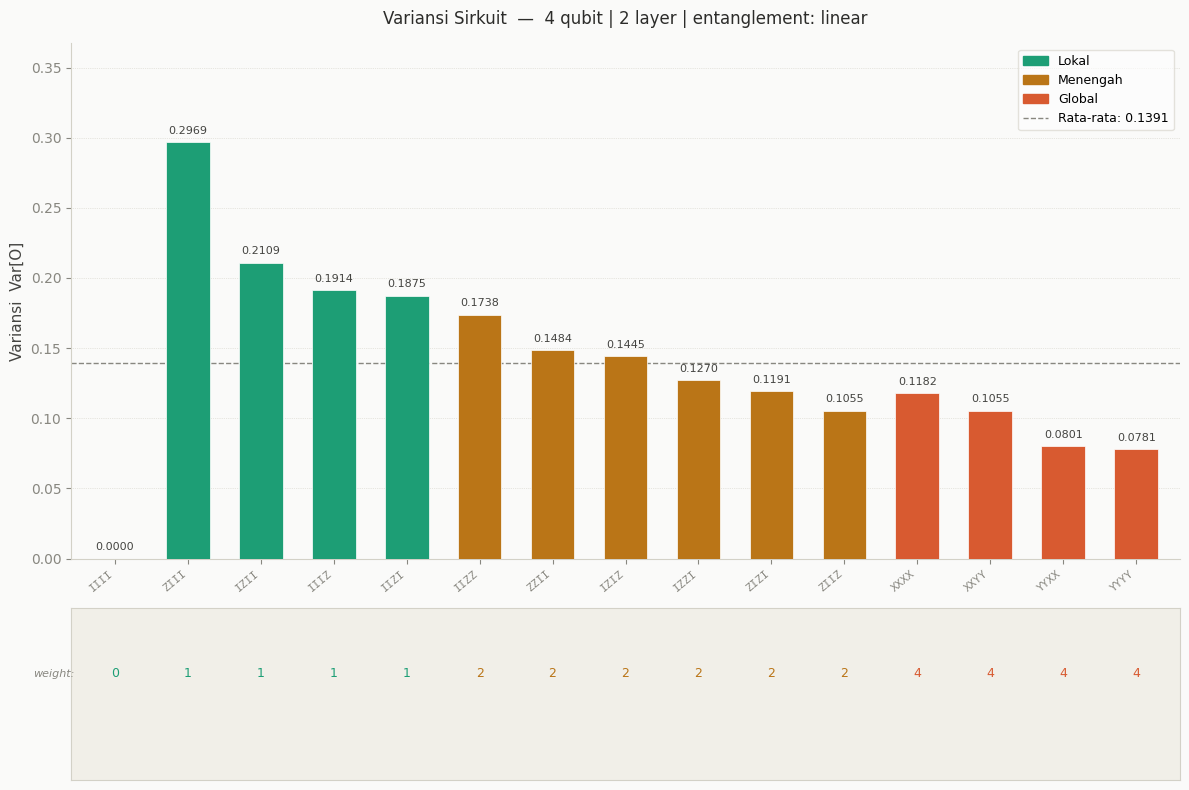

In [6]:
# ==========================================
# SIMULASI VARIANSI SIRKUIT DANGKAL
# Fleksibel: N Qubit, L Layer CNOT, Visualisasi
# ==========================================

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

CNOT_TABLE = {
    'II': 'II', 'IX': 'IX', 'IY': 'ZY', 'IZ': 'ZZ',
    'XI': 'XX', 'XX': 'XI', 'XY': 'YZ', 'XZ': 'YY',
    'YI': 'YX', 'YX': 'YI', 'YY': 'XZ', 'YZ': 'XY',
    'ZI': 'ZI', 'ZX': 'ZX', 'ZY': 'IY', 'ZZ': 'IZ'
}

# ==========================================
# CORE: BACKWARD PAULI PROPAGATION
# ==========================================

def apply_ry_layer_backward(dist):
    new_dist = {}
    for p_string, prob in dist.items():
        current_dists = {"": prob}
        for char in p_string:
            next_dists = {}
            for prefix, p in current_dists.items():
                if char == 'I':
                    next_dists[prefix + 'I'] = next_dists.get(prefix + 'I', 0.0) + p
                elif char == 'Y':
                    next_dists[prefix + 'Y'] = next_dists.get(prefix + 'Y', 0.0) + p
                else:  # X atau Z → bercabang
                    next_dists[prefix + 'X'] = next_dists.get(prefix + 'X', 0.0) + p * 0.5
                    next_dists[prefix + 'Z'] = next_dists.get(prefix + 'Z', 0.0) + p * 0.5
            current_dists = next_dists
        for s, p in current_dists.items():
            new_dist[s] = new_dist.get(s, 0.0) + p
    return new_dist

def apply_cnot_backward(dist, control, target, num_qubits):
    new_dist = {}
    for p_string, prob in dist.items():
        chars = list(p_string)
        idx_c = num_qubits - 1 - control
        idx_t = num_qubits - 1 - target
        pair = chars[idx_c] + chars[idx_t]
        new_pair = CNOT_TABLE[pair]
        chars[idx_c] = new_pair[0]
        chars[idx_t] = new_pair[1]
        new_p_string = "".join(chars)
        new_dist[new_p_string] = new_dist.get(new_p_string, 0.0) + prob
    return new_dist

# ==========================================
# POLA ENTANGLEMENT
# ==========================================

def get_cnot_pairs(entanglement, num_qubits):
    """
    Menghasilkan daftar pasangan (control, target) CNOT
    berdasarkan pola entanglement yang dipilih.

    Pola yang tersedia:
      'linear'    : 0-1, 1-2, 2-3, ..., (n-2)-(n-1)
      'circular'  : linear + tambahan (n-1)-0
      'full'      : semua pasangan unik (i, j) dengan i < j
      'odd_even'  : pasangan (0,1), (2,3), ... lalu (1,2), (3,4), ...
      list        : pasangan custom, contoh [(0,1),(2,3),(1,3)]
    """
    if isinstance(entanglement, list):
        return entanglement

    if entanglement == 'linear':
        return [(i, i + 1) for i in range(num_qubits - 1)]

    elif entanglement == 'circular':
        pairs = [(i, i + 1) for i in range(num_qubits - 1)]
        pairs.append((num_qubits - 1, 0))
        return pairs

    elif entanglement == 'full':
        return [(i, j) for i in range(num_qubits) for j in range(i + 1, num_qubits)]

    elif entanglement == 'odd_even':
        even_pairs = [(i, i + 1) for i in range(0, num_qubits - 1, 2)]
        odd_pairs  = [(i, i + 1) for i in range(1, num_qubits - 1, 2)]
        return even_pairs + odd_pairs

    else:
        raise ValueError(
            f"Pola entanglement '{entanglement}' tidak dikenal. "
            f"Pilih: 'linear', 'circular', 'full', 'odd_even', atau list pasangan."
        )

# ==========================================
# SIMULASI UTAMA
# ==========================================

def simulasi_sirkuit(observable, num_qubits=4, num_layers=1,
                     entanglement='linear'):
    """
    Simulasi variansi sirkuit parametrik via backward Pauli propagation.

    Parameter:
        observable   : str  — Pauli string (panjang == num_qubits)
        num_qubits   : int  — jumlah qubit
        num_layers   : int  — jumlah lapis CNOT (depth ansatz)
        entanglement : str | list — pola CNOT ('linear', 'circular',
                                   'full', 'odd_even', atau list pasangan)
    Return:
        float — nilai variansi
    """
    # --- validasi ---
    obs = observable.upper()
    if len(obs) != num_qubits:
        raise ValueError(
            f"Panjang observabel ({len(obs)}) != num_qubits ({num_qubits})"
        )
    if not all(c in 'IXYZ' for c in obs):
        raise ValueError(f"Karakter tidak valid pada '{observable}'. Gunakan I/X/Y/Z.")
    if num_layers < 1:
        raise ValueError("num_layers harus >= 1.")

    cnot_pairs = get_cnot_pairs(entanglement, num_qubits)
    dist = {obs: 1.0}

    # Struktur ansatz: [Ry — CNOT] × L — Ry
    # Backward: Ry_akhir → (CNOT → Ry) × L
    dist = apply_ry_layer_backward(dist)
    for _ in range(num_layers):
        for ctrl, tgt in cnot_pairs:
            dist = apply_cnot_backward(dist, ctrl, tgt, num_qubits)
        dist = apply_ry_layer_backward(dist)

    variance = sum(
    prob for p_str, prob in dist.items()
    if all(c in ('I', 'Z') for c in p_str)
    and any(c == 'Z' for c in p_str)   # ← tambahkan ini
    )
    
    return variance

def simulasi_batch(observables, num_qubits=4, num_layers=1,
                   entanglement='linear'):
    """
    Simulasi untuk array Pauli string sekaligus.

    Return:
        list of dict: observabel, weight, variansi, kategori
    """
    hasil = []
    for obs in observables:
        try:
            var = simulasi_sirkuit(obs, num_qubits, num_layers, entanglement)
            weight = sum(1 for c in obs.upper() if c != 'I')
            if weight <= 1:
                kategori = "Lokal"
            elif weight == num_qubits:
                kategori = "Global"
            else:
                kategori = "Menengah"
            hasil.append({
                "observabel": obs.upper(),
                "weight":     weight,
                "variansi":   var,
                "kategori":   kategori,
            })
        except ValueError as e:
            print(f"[SKIP] {obs}: {e}")
    return hasil

# ==========================================
# CETAK TABEL
# ==========================================

def cetak_hasil(hasil, num_qubits, num_layers, entanglement):
    ent_label = entanglement if isinstance(entanglement, str) else "custom"
    print(f"\nKONFIGURASI : {num_qubits} qubit | {num_layers} layer | entanglement={ent_label}")
    print("=" * 68)
    print(f"{'Observabel':<{num_qubits+2}} | {'Weight':<7} | {'Variansi':<12} | Kategori")
    print("-" * 68)
    for r in hasil:
        print(
            f"{r['observabel']:<{num_qubits+2}} | "
            f"{r['weight']:<7} | "
            f"{r['variansi']:.6f}   | "
            f"{r['kategori']}"
        )

# ==========================================
# VISUALISASI
# ==========================================

COLOR_MAP = {
    "Lokal":    "#1D9E75",
    "Menengah": "#BA7517",
    "Global":   "#D85A30",
}

def visualisasi_variansi(hasil, num_qubits, num_layers, entanglement):
    if not hasil:
        print("Tidak ada data untuk divisualisasikan.")
        return

    ent_label = entanglement if isinstance(entanglement, str) else "custom"

    # sort by weight lalu variansi descending
    hasil_sorted = sorted(hasil, key=lambda r: (r["weight"], -r["variansi"]))

    labels   = [r["observabel"] for r in hasil_sorted]
    variansi = [r["variansi"]   for r in hasil_sorted]
    kategori = [r["kategori"]   for r in hasil_sorted]
    weights  = [r["weight"]     for r in hasil_sorted]
    colors   = [COLOR_MAP[k]    for k in kategori]

    n      = len(labels)
    x      = np.arange(n)
    fig_w  = max(10, n * 0.8)

    fig, axes = plt.subplots(
        2, 1,
        figsize=(fig_w, 8),
        gridspec_kw={"height_ratios": [3, 1]},
        facecolor="#FAFAF9"
    )
    fig.subplots_adjust(hspace=0.08)

    # ── Panel atas: histogram ──────────────────────────────────
    ax = axes[0]
    ax.set_facecolor("#FAFAF9")

    bars = ax.bar(x, variansi, color=colors, width=0.6,
                  linewidth=0.5, edgecolor="white", zorder=3)

    for bar, val in zip(bars, variansi):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + max(variansi) * 0.015,
            f"{val:.4f}",
            ha="center", va="bottom", fontsize=8, color="#444441"
        )

    mean_var = np.mean(variansi)
    ax.axhline(mean_var, color="#888780", linewidth=1, linestyle="--", zorder=2)

    ax.set_title(
        f"Variansi Sirkuit  —  {num_qubits} qubit | {num_layers} layer | "
        f"entanglement: {ent_label}",
        fontsize=12, fontweight="medium", color="#2C2C2A", pad=14
    )
    ax.set_ylabel("Variansi  Var[O]", fontsize=11, color="#444441")
    ax.set_xticks(x)
    ax.set_xticklabels(labels, rotation=40, ha="right",
                       fontsize=8, fontfamily="monospace")
    ax.set_xlim(-0.6, n - 0.4)
    ax.set_ylim(0, max(variansi) * 1.22 + 0.005)
    ax.yaxis.grid(True, linestyle=":", linewidth=0.5, color="#D3D1C7", zorder=0)
    ax.set_axisbelow(True)
    ax.spines[["top", "right"]].set_visible(False)
    ax.spines[["left", "bottom"]].set_color("#D3D1C7")
    ax.tick_params(colors="#888780")

    legend_patches = [mpatches.Patch(color=c, label=k) for k, c in COLOR_MAP.items()]
    legend_patches.append(
        plt.Line2D([0], [0], color="#888780", linestyle="--",
                   linewidth=1, label=f"Rata-rata: {mean_var:.4f}")
    )
    ax.legend(handles=legend_patches, loc="upper right",
              fontsize=9, framealpha=0.6, edgecolor="#D3D1C7")

    # ── Panel bawah: strip weight ──────────────────────────────
    ax2 = axes[1]
    ax2.set_facecolor("#F1EFE8")
    ax2.set_xlim(-0.6, n - 0.4)
    ax2.set_ylim(0, 1)
    ax2.set_xticks([])
    ax2.set_yticks([])
    ax2.spines[:].set_color("#D3D1C7")

    for i, (w, k) in enumerate(zip(weights, kategori)):
        ax2.text(i, 0.62, str(w), ha="center", va="center",
                 fontsize=9, color=COLOR_MAP[k], fontweight="medium")

    ax2.text(-0.55, 0.62, "weight:", ha="right", va="center",
             fontsize=8, color="#888780", style="italic")

    fname = f"variansi_{num_qubits}q_{num_layers}l_{ent_label}.png"
    plt.tight_layout()
    plt.show()

# ==========================================
# CONTOH PENGGUNAAN
# ==========================================

if __name__ == "__main__":

    # ── Konfigurasi ansatz ─────────────────────────────────────
    NUM_QUBITS   = 4
    NUM_LAYERS   = 2
    ENTANGLEMENT = 'linear'   # 'linear' | 'circular' | 'full' | 'odd_even' | list

    # ── Array Pauli string (panjang harus == NUM_QUBITS) ───────
    observables = ['IIII', 'IIIZ', 'IIZI', 'IZII', 'ZIII', 'IIZZ', 'IZIZ', 'ZIIZ', 'YYYY', 'XXYY', 'YYXX', 'XXXX', 'IZZI', 'ZIZI', 'ZZII']


    hasil = simulasi_batch(observables, NUM_QUBITS, NUM_LAYERS, ENTANGLEMENT)
    cetak_hasil(hasil, NUM_QUBITS, NUM_LAYERS, ENTANGLEMENT)
    visualisasi_variansi(hasil, NUM_QUBITS, NUM_LAYERS, ENTANGLEMENT)